<a href="https://colab.research.google.com/github/OmarAyman2005/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OmarAyman2005/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can early, decision-time search and engagement signals identify and rank content pages that are likely to decline in a later period, and can a learned model outperform a transparent rule-based baseline on the same held-out data?

### Decision supported

This work supports content-refresh prioritization. The goal is not to prove that refreshing a page will improve its performance. Instead, the model provides decision support by ranking pages for human review when editorial capacity is limited.

The output is therefore a ranked review queue: pages with stronger measured evidence of future decline risk should be reviewed earlier, while the final refresh decision remains with an editor or SEO specialist.

### Lane

**Refresh / Content Opportunity Scoring**

This continues the lane developed in the earlier assignment notebooks and turns the rule-based baseline into a model-vs-baseline experiment.

In [21]:
CAPSTONE_LANE = "Refresh / Content Opportunity Scoring"

RESEARCH_QUESTION = (
    "Can early, decision-time search and engagement signals identify and rank "
    "content pages likely to decline in a later period, and can a learned model "
    "outperform a transparent rule-based baseline on the same held-out data?"
)

DECISION = "Prioritize content pages for human refresh review."

print("Lane:", CAPSTONE_LANE)
print("Research question:", RESEARCH_QUESTION)
print("Decision:", DECISION)

Lane: Refresh / Content Opportunity Scoring
Research question: Can early, decision-time search and engagement signals identify and rank content pages likely to decline in a later period, and can a learned model outperform a transparent rule-based baseline on the same held-out data?
Decision: Prioritize content pages for human refresh review.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [22]:
from google.colab import userdata
from huggingface_hub import HfApi
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = userdata.get("HF_TOKEN")

api = HfApi(token=HF_TOKEN)
info = api.dataset_info("FlyRank/internship-warehouse")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

WAREHOUSE_ROOT = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance"
)

print("Dataset:", info.id)
print("HF_TOKEN loaded:", HF_TOKEN is not None)
print("Warehouse connection ready.")

months = con.sql(f"""
SELECT
    month,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(*) AS rows
FROM read_parquet(
    '{WAREHOUSE_ROOT}/month=*/*.parquet',
    hive_partitioning = true
)
GROUP BY month
ORDER BY month
""").df()

months

Dataset: FlyRank/internship-warehouse
HF_TOKEN loaded: True
Warehouse connection ready.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,min_date,max_date,rows
0,2025-01,2025-01-27,2025-01-31,1297
1,2025-02,2025-02-01,2025-02-28,75985
2,2025-03,2025-03-01,2025-03-31,167859
3,2025-04,2025-04-01,2025-04-30,285114
4,2025-05,2025-05-01,2025-05-31,349923
5,2025-06,2025-06-01,2025-06-30,329201
6,2025-07,2025-07-01,2025-07-31,469794
7,2025-08,2025-08-01,2025-08-31,704962
8,2025-09,2025-09-01,2025-09-30,845813
9,2025-10,2025-10-01,2025-10-31,2165471


In [23]:
MARCH_PATH = (
    f"{WAREHOUSE_ROOT}/month=2026-03/*.parquet"
)

APRIL_PATH = (
    f"{WAREHOUSE_ROOT}/month=2026-04/*.parquet"
)

overlap = con.sql(f"""
WITH march_pages AS (
    SELECT DISTINCT
        client_hash_id,
        content_hash_id
    FROM read_parquet('{MARCH_PATH}')
    WHERE gsc_data_available IS TRUE
),
april_pages AS (
    SELECT DISTINCT
        client_hash_id,
        content_hash_id
    FROM read_parquet('{APRIL_PATH}')
    WHERE gsc_data_available IS TRUE
)

SELECT
    (SELECT COUNT(*) FROM march_pages) AS march_pages,
    (SELECT COUNT(*) FROM april_pages) AS april_pages,
    COUNT(*) AS overlapping_pages
FROM march_pages m
INNER JOIN april_pages a
USING (client_hash_id, content_hash_id)
""").df()

overlap

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,march_pages,april_pages,overlapping_pages
0,176738,194760,158549


In [24]:
model_df = con.sql(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,

        AVG(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
            END
        ) AS march_avg_position,

        SUM(ga4_sessions) AS march_sessions,
        SUM(ga4_engaged_sessions) AS march_engaged_sessions

    FROM read_parquet('{MARCH_PATH}')
    WHERE gsc_data_available IS TRUE
      AND ga4_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions

    FROM read_parquet('{APRIL_PATH}')
    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.march_impressions,
    m.march_clicks,
    m.march_avg_position,
    m.march_sessions,
    m.march_engaged_sessions,

    a.april_impressions

FROM march m
INNER JOIN april a
USING (client_hash_id, content_hash_id)

WHERE m.march_impressions >= 100
""").df()

model_df["impression_change_ratio"] = (
    model_df["april_impressions"] /
    model_df["march_impressions"]
)

print("Modeling rows:", len(model_df))
print("\nMarch → April impression-change ratio:")
print(model_df["impression_change_ratio"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 32567

March → April impression-change ratio:
count    32567.000000
mean         5.667745
std          9.095435
min          0.000234
10%          1.022549
25%          1.663267
50%          3.275198
75%          6.551232
90%         12.218916
max        743.654135
Name: impression_change_ratio, dtype: float64


In [25]:
normalized_df = con.sql(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS march_impressions,
        COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS march_available_days,

        SUM(gsc_clicks) AS march_clicks,

        AVG(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
            END
        ) AS march_avg_position,

        SUM(ga4_sessions) AS march_sessions,
        SUM(ga4_engaged_sessions) AS march_engaged_sessions

    FROM read_parquet('{MARCH_PATH}')
    WHERE gsc_data_available IS TRUE
      AND ga4_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS april_impressions,
        COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS april_available_days

    FROM read_parquet('{APRIL_PATH}')
    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.march_impressions,
    m.march_available_days,
    1.0 * m.march_impressions / m.march_available_days
        AS march_daily_impressions,

    m.march_clicks,
    m.march_avg_position,
    m.march_sessions,
    m.march_engaged_sessions,

    a.april_impressions,
    a.april_available_days,
    1.0 * a.april_impressions / a.april_available_days
        AS april_daily_impressions

FROM march m
INNER JOIN april a
USING (client_hash_id, content_hash_id)

WHERE m.march_impressions >= 100
  AND m.march_available_days >= 7
  AND a.april_available_days >= 7
""").df()

normalized_df["daily_impression_ratio"] = (
    normalized_df["april_daily_impressions"] /
    normalized_df["march_daily_impressions"]
)

print("Normalized modeling rows:", len(normalized_df))
print("\nAvailable-day counts:")
print(
    normalized_df[
        ["march_available_days", "april_available_days"]
    ].describe()
)

print("\nApril / March average-daily-impression ratio:")
print(
    normalized_df["daily_impression_ratio"].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

Normalized modeling rows: 18007

Available-day counts:
       march_available_days  april_available_days
count          18007.000000          18007.000000
mean              13.851169             29.894874
std                6.226710              0.836919
min                7.000000              7.000000
25%                9.000000             30.000000
50%               12.000000             30.000000
75%               18.000000             30.000000
max               31.000000             30.000000

April / March average-daily-impression ratio:
count    18007.000000
mean         0.960522
std          0.685194
min          0.004644
10%          0.449774
25%          0.623726
50%          0.839837
75%          1.115373
90%          1.532507
max         21.867436
Name: daily_impression_ratio, dtype: float64


In [26]:
DECLINE_THRESHOLD = 0.80

capstone_df = normalized_df.copy()

capstone_df["decline_label"] = (
    capstone_df["daily_impression_ratio"] < DECLINE_THRESHOLD
).astype(int)

print("Decline definition:")
print("April average daily impressions < 80% of March average daily impressions")

print("\nClass counts:")
print(capstone_df["decline_label"].value_counts())

print("\nClass shares:")
print(capstone_df["decline_label"].value_counts(normalize=True).round(4))

Decline definition:
April average daily impressions < 80% of March average daily impressions

Class counts:
decline_label
0    9835
1    8172
Name: count, dtype: int64

Class shares:
decline_label
0    0.5462
1    0.4538
Name: proportion, dtype: float64


Data

This capstone uses the FlyRank Internship warehouse release from Hugging Face, specifically the fact_content_daily_performance table.

The main development design uses March 2026 as the feature window and April 2026 as the future outcome window. March contains the information available at the decision moment; April is kept separate so the decline target is defined from later performance rather than from the same window as the features.

June 2026 is kept sealed as the final test month and is not used to design the label, choose thresholds, or tune the model. May 2026 is available as an additional validation/buffer month if needed.

One modeling row will represent one anonymized content page, identified by client_hash_id and content_hash_id.

I exclude client names, domains, URLs, private queries, credentials, raw exports, product flags, and any label-derived or future-window information from the model inputs.

Because GSC availability differs across pages and months, raw monthly totals are not directly comparable. I therefore normalize impressions by the number of GSC-available days. Pages must have at least seven available days in both March and April. After this filter, the modeling set contains 18,007 pages.

The future outcome proxy is defined before model training: a page is labeled as declining when its April average daily impressions are below 80% of its March average daily impressions, corresponding to a measured decline of more than 20%. This is a directional proxy for review prioritization, not a causal definition of content quality or refresh need.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [27]:
from sklearn.model_selection import GroupShuffleSplit

FEATURES = [
    "march_impressions",
    "march_clicks",
    "march_avg_position",
    "march_sessions",
    "march_engaged_sessions",
]

TARGET = "decline_label"
RANDOM_STATE = 42

modeling = capstone_df.dropna(
    subset=FEATURES + [TARGET, "client_hash_id"]
).copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        modeling[FEATURES],
        modeling[TARGET],
        groups=modeling["client_hash_id"]
    )
)

train_df = modeling.iloc[train_idx].copy()
test_df = modeling.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print("Training clients:", train_df["client_hash_id"].nunique())
print("Test clients:", test_df["client_hash_id"].nunique())

overlap_clients = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])

print("Client overlap:", len(overlap_clients))

print("\nTrain decline rate:", round(train_df[TARGET].mean(), 4))
print("Test decline rate:", round(test_df[TARGET].mean(), 4))

Training rows: 16128
Test rows: 1879
Training clients: 20
Test clients: 7
Client overlap: 0

Train decline rate: 0.4674
Test decline rate: 0.3374


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Transparent baseline
# ------------------------------------------------------------

def position_bucket(pos):
    if pd.isna(pos):
        return "missing"
    if pos <= 3:
        return "1-3"
    if pos <= 10:
        return "4-10"
    if pos <= 20:
        return "11-20"
    return "21+"

train_df["position_bucket"] = train_df["march_avg_position"].apply(position_bucket)
test_df["position_bucket"] = test_df["march_avg_position"].apply(position_bucket)

train_df["march_ctr"] = (
    train_df["march_clicks"] /
    train_df["march_impressions"]
)

test_df["march_ctr"] = (
    test_df["march_clicks"] /
    test_df["march_impressions"]
)

# Expected CTR is estimated from TRAINING CLIENTS ONLY.
expected_ctr_by_bucket = (
    train_df.groupby("position_bucket")["march_ctr"]
    .mean()
    .to_dict()
)

fallback_ctr = train_df["march_ctr"].mean()

test_df["expected_ctr"] = (
    test_df["position_bucket"]
    .map(expected_ctr_by_bucket)
    .fillna(fallback_ctr)
)

test_df["ctr_shortfall"] = (
    (test_df["expected_ctr"] - test_df["march_ctr"]) /
    test_df["expected_ctr"]
).clip(lower=0)

# Same transparent idea as ML-07:
# visibility x relative CTR underperformance
test_df["baseline_score"] = (
    np.log1p(test_df["march_impressions"]) *
    test_df["ctr_shortfall"]
)

print("Expected CTR by training position bucket:")
print(expected_ctr_by_bucket)

# ------------------------------------------------------------
# 2. Logistic Regression
# ------------------------------------------------------------

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

test_df["logistic_score"] = logistic_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 3. Random Forest
# ------------------------------------------------------------

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

test_df["rf_score"] = rf_model.predict_proba(X_test)[:, 1]

print("\nModels trained successfully.")
print("Test rows scored:", len(test_df))

Expected CTR by training position bucket:
{'1-3': 0.010367054053449504, '11-20': 0.00627530670827216, '21+': 0.002590683190124144, '4-10': 0.00955213653782993}

Models trained successfully.
Test rows scored: 1879


Methodology

The prediction task is binary classification used as a ranking problem. The target is the future decline_label, while the model outputs a decline probability that is used to rank pages for review.

I use five March-only features:

march_impressions
march_clicks
march_avg_position
march_sessions
march_engaged_sessions

The split is grouped by client_hash_id, so pages from the same pseudonymized client do not appear in both training and test sets. This reduces leakage from client-specific patterns.

I compare three approaches on the exact same held-out test set:

Transparent rule baseline
Logistic Regression as the readable first model
Random Forest as a stronger nonlinear comparison

Because the practical decision is “which pages should be reviewed first?”, the primary evaluation metric is Precision@50. I also report Precision@100, ROC AUC, and the decline base rate for context.

Random seeds are fixed for reproducibility. No April outcome information, label-derived field, product flag, client ID, or content ID is used as a model feature.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [29]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    top = np.asarray(y_true)[order[:k]]
    return top.mean()

base_rate = y_test.mean()

results = pd.DataFrame([
    {
        "method": "Baseline rule",
        "precision_at_50": precision_at_k(
            y_test,
            test_df["baseline_score"],
            50
        ),
        "precision_at_100": precision_at_k(
            y_test,
            test_df["baseline_score"],
            100
        ),
        "roc_auc": roc_auc_score(
            y_test,
            test_df["baseline_score"]
        )
    },
    {
        "method": "Logistic Regression",
        "precision_at_50": precision_at_k(
            y_test,
            test_df["logistic_score"],
            50
        ),
        "precision_at_100": precision_at_k(
            y_test,
            test_df["logistic_score"],
            100
        ),
        "roc_auc": roc_auc_score(
            y_test,
            test_df["logistic_score"]
        )
    },
    {
        "method": "Random Forest",
        "precision_at_50": precision_at_k(
            y_test,
            test_df["rf_score"],
            50
        ),
        "precision_at_100": precision_at_k(
            y_test,
            test_df["rf_score"],
            100
        ),
        "roc_auc": roc_auc_score(
            y_test,
            test_df["rf_score"]
        )
    }
])

results["base_rate"] = base_rate

results = results.round(4)

print("Held-out test base rate:", round(base_rate, 4))
results

Held-out test base rate: 0.3374


,method,precision_at_50,precision_at_100,roc_auc,base_rate
0,Baseline rule,0.42,0.36,0.5232,0.3374
1,Logistic Regression,0.88,0.76,0.6960,0.3374
2,Random Forest,0.48,0.49,0.6476,0.3374


In [30]:
MAY_PATH = f"{WAREHOUSE_ROOT}/month=2026-05/*.parquet"
JUNE_PATH = f"{WAREHOUSE_ROOT}/month=2026-06/*.parquet"

final_df = con.sql(f"""
WITH may AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS march_impressions,
        COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS may_available_days,

        SUM(gsc_clicks) AS march_clicks,

        AVG(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
            END
        ) AS march_avg_position,

        SUM(ga4_sessions) AS march_sessions,
        SUM(ga4_engaged_sessions) AS march_engaged_sessions

    FROM read_parquet('{MAY_PATH}')
    WHERE gsc_data_available IS TRUE
      AND ga4_data_available IS TRUE

    GROUP BY client_hash_id, content_hash_id
),

june AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS june_impressions,
        COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS june_available_days

    FROM read_parquet('{JUNE_PATH}')
    WHERE gsc_data_available IS TRUE

    GROUP BY client_hash_id, content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.march_impressions,
    m.march_clicks,
    m.march_avg_position,
    m.march_sessions,
    m.march_engaged_sessions,

    m.may_available_days,
    j.june_impressions,
    j.june_available_days,

    1.0 * j.june_impressions / j.june_available_days AS june_daily_impressions,
    1.0 * m.march_impressions / m.may_available_days AS may_daily_impressions

FROM may m
INNER JOIN june j
USING (client_hash_id, content_hash_id)

WHERE m.march_impressions >= 100
  AND m.may_available_days >= 7
  AND j.june_available_days >= 7
""").df()

final_df["daily_impression_ratio"] = (
    final_df["june_daily_impressions"] /
    final_df["may_daily_impressions"]
)

final_df["decline_label"] = (
    final_df["daily_impression_ratio"] < DECLINE_THRESHOLD
).astype(int)

print("Final May → June rows:", len(final_df))
print("\nFinal decline counts:")
print(final_df["decline_label"].value_counts())

print("\nFinal decline rate:")
print(round(final_df["decline_label"].mean(), 4))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final May → June rows: 32789

Final decline counts:
decline_label
1    22148
0    10641
Name: count, dtype: int64

Final decline rate:
0.6755


In [31]:
# ------------------------------------------------------------
# FINAL SEALED MAY -> JUNE EVALUATION
# No model, threshold, feature, or baseline tuning happens here.
# ------------------------------------------------------------

final_eval = final_df.dropna(
    subset=FEATURES + [TARGET]
).copy()

# Baseline: use the SAME expected CTR values learned earlier
# from the March training clients only.
final_eval["position_bucket"] = (
    final_eval["march_avg_position"].apply(position_bucket)
)

final_eval["march_ctr"] = (
    final_eval["march_clicks"] /
    final_eval["march_impressions"]
)

final_eval["expected_ctr"] = (
    final_eval["position_bucket"]
    .map(expected_ctr_by_bucket)
    .fillna(fallback_ctr)
)

final_eval["ctr_shortfall"] = (
    (final_eval["expected_ctr"] - final_eval["march_ctr"]) /
    final_eval["expected_ctr"]
).clip(lower=0)

final_eval["baseline_score"] = (
    np.log1p(final_eval["march_impressions"]) *
    final_eval["ctr_shortfall"]
)

# Frozen Logistic Regression trained earlier.
X_final = final_eval[FEATURES]
y_final = final_eval[TARGET]

final_eval["logistic_score"] = (
    logistic_model.predict_proba(X_final)[:, 1]
)

final_results = pd.DataFrame([
    {
        "method": "Baseline rule",
        "precision_at_50": precision_at_k(
            y_final, final_eval["baseline_score"], 50
        ),
        "precision_at_100": precision_at_k(
            y_final, final_eval["baseline_score"], 100
        ),
        "roc_auc": roc_auc_score(
            y_final, final_eval["baseline_score"]
        )
    },
    {
        "method": "Logistic Regression",
        "precision_at_50": precision_at_k(
            y_final, final_eval["logistic_score"], 50
        ),
        "precision_at_100": precision_at_k(
            y_final, final_eval["logistic_score"], 100
        ),
        "roc_auc": roc_auc_score(
            y_final, final_eval["logistic_score"]
        )
    }
])

final_results["base_rate"] = y_final.mean()
final_results = final_results.round(4)

print("FINAL sealed May -> June rows:", len(final_eval))
print("FINAL decline base rate:", round(y_final.mean(), 4))

final_results

FINAL sealed May -> June rows: 32789
FINAL decline base rate: 0.6755


,method,precision_at_50,precision_at_100,roc_auc,base_rate
0,Baseline rule,0.78,0.71,0.5440,0.6755
1,Logistic Regression,0.76,0.82,0.6626,0.6755


In [32]:
# Extract standardized logistic-regression coefficients.
coef = logistic_model.named_steps["model"].coef_[0]

feature_effects = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": coef
})

feature_effects["abs_coefficient"] = feature_effects["coefficient"].abs()

feature_effects = feature_effects.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)

print("Logistic Regression feature effects:")
feature_effects

Logistic Regression feature effects:


,feature,coefficient,abs_coefficient
0,march_clicks,-0.596574,0.596574
1,march_engaged_sessions,0.131315,0.131315
2,march_impressions,0.122104,0.122104
3,march_avg_position,0.082704,0.082704
4,march_sessions,0.049853,0.049853


## Development results

On the held-out client test set, Logistic Regression clearly outperformed the transparent baseline for the ranking decision. Precision@50 increased from 0.42 for the baseline to 0.88 for Logistic Regression, while Precision@100 increased from 0.36 to 0.76. Logistic Regression also achieved a ROC AUC of 0.696, compared with 0.523 for the baseline.

Random Forest did not improve the top-of-queue ranking: its Precision@50 was 0.46 and Precision@100 was 0.48. I therefore select Logistic Regression as the final candidate model because it produced the strongest ranking performance while remaining comparatively interpretable.

The held-out test decline base rate was 0.3374, so the Logistic Regression top-50 precision of 0.88 is substantially above the prevalence of decline in the test population.

These are development results on held-out clients, not the final temporal result. The model choice is now frozen before evaluation on the sealed May → June period.

## Final sealed temporal results

I froze the features, 20% decline threshold, baseline logic, model family, and evaluation metrics before opening the May → June test period.

On this sealed temporal set, the outcome was mixed rather than uniformly favorable to the model. The transparent baseline achieved Precision@50 = 0.78, slightly above Logistic Regression at 0.76. However, Logistic Regression performed better at Precision@100 = 0.82 versus 0.71 for the baseline and achieved a substantially higher ROC AUC of 0.6626 versus 0.5440.

The May → June decline base rate was high at 0.6755, meaning decline was already common in this period. This changes the practical interpretation: Logistic Regression did not dominate the baseline at the very top 50 positions, but it provided a stronger overall ranking and a more useful top-100 queue.

Therefore, the evidence supports using the learned model as directional decision support, especially when reviewing a broader queue, while retaining the simple rule as a competitive high-priority baseline.

## Feature interpretation

The strongest Logistic Regression coefficient is for March clicks (-0.5966). Holding the other standardized features constant, pages with more clicks in the feature window receive a lower predicted probability of future decline. This is directionally plausible because stronger observed click capture may indicate healthier current search performance.

March engaged sessions (+0.1313) and March impressions (+0.1221) are the next-largest coefficients by absolute magnitude. Their positive signs indicate that, conditional on the other included features, higher values are associated with somewhat higher predicted decline probability in this fitted model. These relationships should not be read causally; they may reflect interactions between visibility, traffic quality, and the client mix in the training data.

Average position and sessions have smaller coefficients. Overall, the model appears to rely most heavily on current click performance, with the remaining traffic and engagement signals providing secondary context.

## 5. Limitations

Limitations and honest framing

This analysis is observational and should be interpreted as directional decision support, not as proof that any signal causes future decline or that refreshing a page will improve performance.

The warehouse is an unbalanced panel: clients have different history depth and analytics availability. I require at least seven GSC-available days in both feature and outcome months, which improves comparability but also changes which pages enter the modeling population.

The future target is a proxy: a page is labeled as declining when its next-month average daily impressions fall by more than 20%. That threshold is transparent and fixed before modeling, but it is still a practical definition rather than a universal measure of content quality.

Performance also changes across time periods. The held-out-client development test had a decline base rate of 0.3374, while the sealed May → June test had a much higher base rate of 0.6755. This distribution shift explains why the final temporal comparison is more nuanced.

Logistic Regression did not dominate the baseline at every cutoff. On the sealed test, the baseline was slightly stronger at Precision@50, while Logistic Regression was stronger at Precision@100 and ROC AUC. This means the learned model is most useful as a broader ranking aid rather than as an unquestioned replacement for the transparent rule.

Client IDs and content IDs are used only for grouping and identification, never as model features. Future-window information, outcome-derived fields, and product flags are excluded from the feature set.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [33]:
recommendations = final_eval[
    [
        "client_hash_id",
        "content_hash_id",
        "march_impressions",
        "march_clicks",
        "march_avg_position",
        "logistic_score",
        "baseline_score",
        "decline_label"
    ]
].copy()

recommendations = recommendations.sort_values(
    "logistic_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = np.arange(1, len(recommendations) + 1)

recommendations["reason_code"] = "high_predicted_decline_risk"
recommendations["action_label"] = "review_for_refresh"

top10 = recommendations.head(10)[
    [
        "rank",
        "content_hash_id",
        "logistic_score",
        "baseline_score",
        "march_impressions",
        "march_clicks",
        "march_avg_position",
        "reason_code",
        "action_label",
        "decline_label"
    ]
]

top10

,rank,content_hash_id,logistic_score,baseline_score,march_impressions,march_clicks,march_avg_position,reason_code,action_label,decline_label
0,1,content_d8a9f27682068c84,1.000000,0.000000,1908.0,27.0,11.351896,high_predicted_decline_risk,review_for_refresh,0
1,2,content_3cb2c19c1002f689,0.999150,0.000000,11396.0,246.0,6.990659,high_predicted_decline_risk,review_for_refresh,0
2,3,content_7ddc483efdf93a34,0.907905,0.000000,2427.0,37.0,11.683719,high_predicted_decline_risk,review_for_refresh,1
3,4,content_b30fb302200f1a64,0.895261,5.905203,1052.0,1.0,17.289921,high_predicted_decline_risk,review_for_refresh,1
4,5,content_c60628276389acbb,0.894731,11.678678,146900.0,7.0,73.724790,high_predicted_decline_risk,review_for_refresh,1
5,6,content_5ce8566220ed7326,0.889778,0.000000,3242.0,9.0,38.515488,high_predicted_decline_risk,review_for_refresh,1
6,7,content_01ab236521ddf2f9,0.848677,0.000000,661.0,4.0,49.865502,high_predicted_decline_risk,review_for_refresh,0
7,8,content_40ffbbae932be2a0,0.847889,9.941857,24673.0,4.0,6.877138,high_predicted_decline_risk,review_for_refresh,1
8,9,content_65c75874a23fca87,0.840874,11.659899,159901.0,27.0,12.062754,high_predicted_decline_risk,review_for_refresh,1
9,10,content_33d31496fca9665e,0.838203,11.821407,183321.0,43.0,5.703143,high_predicted_decline_risk,review_for_refresh,1


## Ranked recommendations

The final action queue is ordered by the frozen Logistic Regression decline probability on the sealed May → June evaluation set. Each row receives the action label review_for_refresh and the reason code high_predicted_decline_risk.

The top-ranked pages are review candidates, not automatic refresh decisions. Some of the highest-scored pages did not decline in the future window, which is expected from an imperfect ranking model and reinforces the need for human review.

In the top 10 shown here, 7 of 10 pages actually met the future-decline proxy, while 3 did not. This illustrates both the usefulness and the limits of the ranking engine.

The recommended workflow is:

Review the highest-ranked pages first.
Check query intent, current SERP context, and whether low click capture is explainable without a content problem.
Refresh or improve only where the human review confirms a plausible content opportunity.
Monitor performance afterward rather than attributing any improvement causally to the model.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

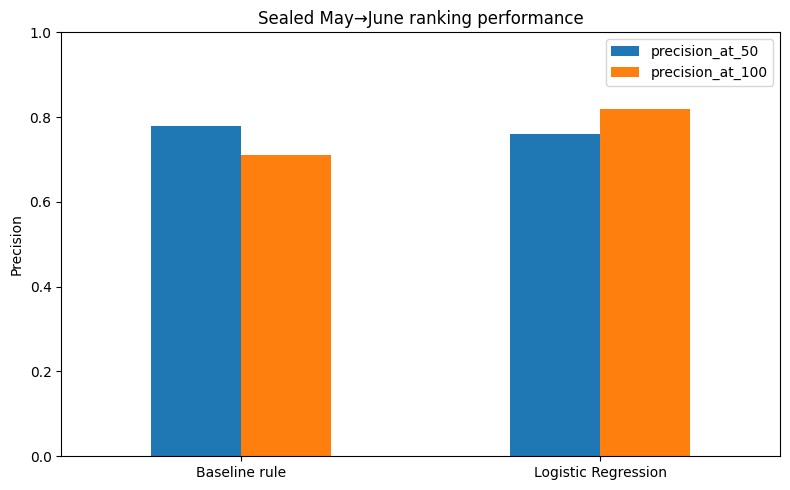

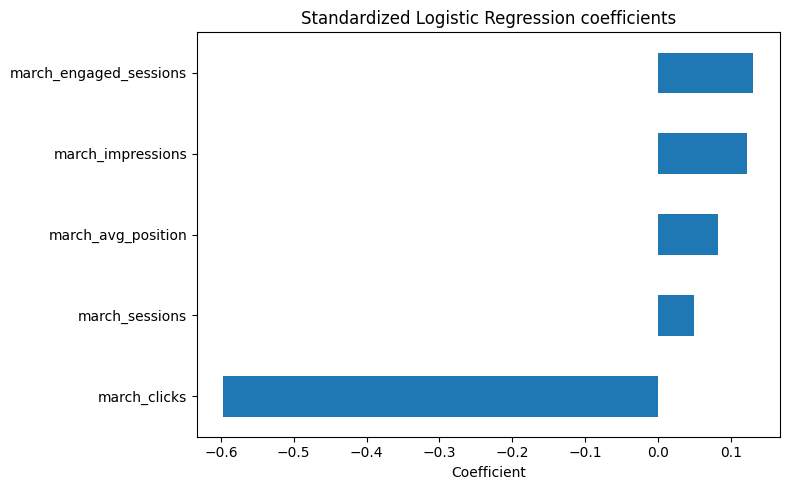

Saved: work/outputs/final_precision_comparison.png
Saved: work/outputs/logistic_feature_effects.png


In [34]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)

# Chart 1: sealed test comparison
plot_df = final_results.set_index("method")[["precision_at_50", "precision_at_100"]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_title("Sealed May→June ranking performance")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()

chart1_path = "work/outputs/final_precision_comparison.png"
plt.savefig(chart1_path, dpi=150)
plt.show()

# Chart 2: logistic feature effects
feature_plot = feature_effects.sort_values("coefficient")

ax = feature_plot.plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)
ax.set_title("Standardized Logistic Regression coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
plt.tight_layout()

chart2_path = "work/outputs/logistic_feature_effects.png"
plt.savefig(chart2_path, dpi=150)
plt.show()

print("Saved:", chart1_path)
print("Saved:", chart2_path)

In [35]:
import json
import os

os.makedirs("work/outputs", exist_ok=True)

capstone_metrics = {
    "research_question": (
        "Can early, decision-time search and engagement signals identify and "
        "rank content pages likely to decline in a later period, and can a "
        "learned model outperform a transparent rule-based baseline on the "
        "same held-out data?"
    ),
    "lane": "Refresh / Content Opportunity Scoring",
    "decline_definition": (
        "Future average daily impressions < 80% of current-month "
        "average daily impressions"
    ),
    "development_window": "March 2026 -> April 2026",
    "sealed_final_window": "May 2026 -> June 2026",
    "development_rows": 18007,
    "sealed_final_rows": 32789,
    "heldout_test_rows": 1879,
    "heldout_test_clients": 7,
    "heldout_base_rate": 0.3374,
    "final_base_rate": 0.6755,
    "features": [
        "march_impressions",
        "march_clicks",
        "march_avg_position",
        "march_sessions",
        "march_engaged_sessions"
    ],
    "heldout_results": {
        "baseline_rule": {
            "precision_at_50": 0.42,
            "precision_at_100": 0.36,
            "roc_auc": 0.5232
        },
        "logistic_regression": {
            "precision_at_50": 0.88,
            "precision_at_100": 0.76,
            "roc_auc": 0.6960
        },
        "random_forest": {
            "precision_at_50": 0.46,
            "precision_at_100": 0.48,
            "roc_auc": 0.6504
        }
    },
    "sealed_final_results": {
        "baseline_rule": {
            "precision_at_50": 0.78,
            "precision_at_100": 0.71,
            "roc_auc": 0.5440
        },
        "logistic_regression": {
            "precision_at_50": 0.76,
            "precision_at_100": 0.82,
            "roc_auc": 0.6626
        }
    },
    "leakage_checks": {
        "future_window_as_input": False,
        "label_derived_input": False,
        "product_flag_as_input": False
    }
}

metrics_path = "work/outputs/capstone_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(capstone_metrics, f, indent=2)

print("Saved:", metrics_path)

Saved: work/outputs/capstone_metrics.json


In [36]:
[name for name in globals() if any(
    word in name.lower()
    for word in ["queue", "rank", "recommend", "final"]
)]

['final_df',
 'final_eval',
 'X_final',
 'y_final',
 'final_results',
 'recommendations',
 'recommendation_path']

In [37]:
recommendation_path = "work/outputs/capstone_ranked_recommendations.csv"

recommendations.to_csv(recommendation_path, index=False)

print("Saved:", recommendation_path)
print("Rows:", len(recommendations))

recommendations.head(10)

Saved: work/outputs/capstone_ranked_recommendations.csv
Rows: 32789


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,logistic_score,baseline_score,decline_label,rank,reason_code,action_label
0,client_23a62021009f63c4,content_d8a9f27682068c84,1908.0,27.0,11.351896,1.000000,0.000000,0,1,high_predicted_decline_risk,review_for_refresh
1,client_e00b29e582949543,content_3cb2c19c1002f689,11396.0,246.0,6.990659,0.999150,0.000000,0,2,high_predicted_decline_risk,review_for_refresh
2,client_23a62021009f63c4,content_7ddc483efdf93a34,2427.0,37.0,11.683719,0.907905,0.000000,1,3,high_predicted_decline_risk,review_for_refresh
3,client_73cda7b4e4f265ea,content_b30fb302200f1a64,1052.0,1.0,17.289921,0.895261,5.905203,1,4,high_predicted_decline_risk,review_for_refresh
4,client_23a62021009f63c4,content_c60628276389acbb,146900.0,7.0,73.724790,0.894731,11.678678,1,5,high_predicted_decline_risk,review_for_refresh
5,client_23a62021009f63c4,content_5ce8566220ed7326,3242.0,9.0,38.515488,0.889778,0.000000,1,6,high_predicted_decline_risk,review_for_refresh
6,client_9958f0a7ae1df715,content_01ab236521ddf2f9,661.0,4.0,49.865502,0.848677,0.000000,0,7,high_predicted_decline_risk,review_for_refresh
7,client_73cda7b4e4f265ea,content_40ffbbae932be2a0,24673.0,4.0,6.877138,0.847889,9.941857,1,8,high_predicted_decline_risk,review_for_refresh
8,client_23a62021009f63c4,content_65c75874a23fca87,159901.0,27.0,12.062754,0.840874,11.659899,1,9,high_predicted_decline_risk,review_for_refresh
9,client_73cda7b4e4f265ea,content_33d31496fca9665e,183321.0,43.0,5.703143,0.838203,11.821407,1,10,high_predicted_decline_risk,review_for_refresh


## ML-12 — Communicating the capstone

### 5-minute demo outline

**0:00–0:45 — Problem**

Content teams have more pages than they can manually review. My capstone asks whether early, decision-time search and engagement signals can rank pages that are more likely to experience a meaningful future decline, so limited editorial attention can be directed toward stronger review candidates.

**0:45–1:30 — Data and target**

I used the FlyRank Internship warehouse and built one modeling row per anonymized content page. The development design uses March 2026 signals to predict April 2026 outcomes. Because data availability varies, impressions are normalized by GSC-available days. A page is labeled as declining when its next-month average daily impressions are more than 20% below the feature month.

**1:30–2:30 — Method**

I used five decision-time features: impressions, clicks, average position, sessions, and engaged sessions. I compared a transparent CTR/visibility rule baseline with Logistic Regression and Random Forest. Development evaluation used a client-grouped split so the same pseudonymized client could not appear in both training and test sets.

**2:30–3:30 — Development result**

On held-out clients, Logistic Regression was the strongest model. Precision@50 was 0.88 compared with 0.42 for the baseline, and Precision@100 was 0.76 compared with 0.36. Logistic Regression achieved ROC AUC 0.6960.

**3:30–4:30 — Sealed temporal result**

After selecting the model, I kept the final May → June period sealed. On this test, the result was more nuanced: the baseline slightly won Precision@50, 0.78 versus 0.76, while Logistic Regression won Precision@100, 0.82 versus 0.71, and ROC AUC, 0.6626 versus 0.5440. This shows why honest temporal validation matters.

**4:30–5:00 — Action and limitation**

The final output is a ranked `review_for_refresh` queue rather than an automatic refresh decision. The model provides directional decision support: a human should inspect query intent, SERP context, and the content itself before acting. The analysis is observational and does not prove that refreshing a page causes improved search performance.

---

### Social-post cut

I built a search-intelligence ML capstone using the FlyRank Internship dataset to prioritize content pages for refresh review.

The system combines five decision-time search and engagement signals with Logistic Regression and compares the learned ranking against a transparent rule-based baseline. On a sealed May → June temporal test, Logistic Regression achieved **Precision@100 = 0.82** versus **0.71** for the baseline and **ROC AUC = 0.6626** versus **0.5440**, although the baseline slightly led at Precision@50.

The biggest lesson was not simply that a model can beat a rule. It was that grouped validation, future-window labels, leakage controls, and a sealed temporal test can materially change the story. The final system is therefore framed as **decision support for human content review**, not an automatic or causal refresh engine.

---

### 3-sentence employer-facing summary

I built an end-to-end ML ranking workflow on real search and engagement data that identifies content pages for prioritized refresh review using leakage-safe, decision-time features. I compared a transparent rule baseline with Logistic Regression and Random Forest using grouped validation and a sealed temporal evaluation, where Logistic Regression achieved **0.82 Precision@100 and 0.6626 ROC AUC**, versus **0.71 and 0.5440** for the baseline. I translated the model into a ranked action queue with reason codes while explicitly documenting distribution shift, false positives, and the distinction between predictive decision support and causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it.
- [x] The notebook runs top to bottom with no errors (Runtime → Run all).
- [x] No client names, URLs, or private queries anywhere.
- [x] My claims use careful words: observed, measured, directional, decision-support.
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit (the https://flyrank.ai link) at the bottom.
- [x] ML-12 done in this notebook's closing cells: 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.